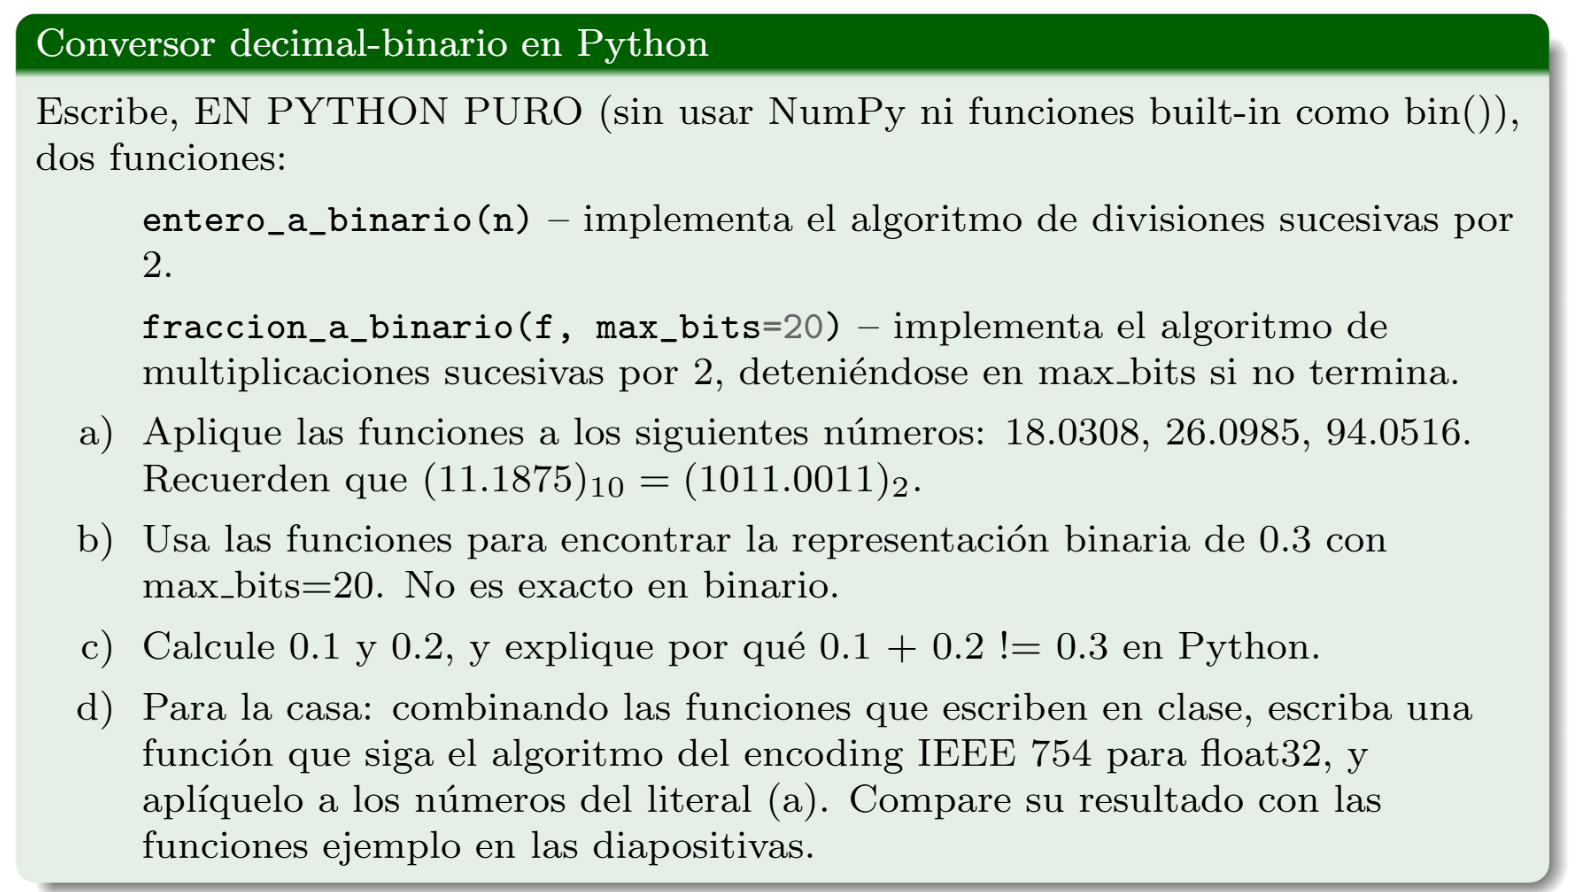

In [3]:

# DEFINICIÓN DE FUNCIONES 


def entero_a_binario(n):
    if n == 0:
        return "0"
    
    binario = ""
    while n > 0:
        residuo = n % 2
        binario = str(residuo) + binario
        n = n // 2
    return binario


def fraccion_a_binario(f, max_bits=20):
    binario = ""
    bits = 0
    
    while f > 0 and bits < max_bits:
        f = f * 2
        bit = int(f)
        binario = binario + str(bit)
        f = f - bit
        bits = bits + 1
        
    return binario



In [ ]:
# a) Conversión de 18.0308, 26.0985, 94.0516
num1 = 18.0308
bin1 = entero_a_binario(int(num1)) + "." + fraccion_a_binario(num1 - int(num1), 20)

num2 = 26.0985
bin2 = entero_a_binario(int(num2)) + "." + fraccion_a_binario(num2 - int(num2), 20)

num3 = 94.0516
bin3 = entero_a_binario(int(num3)) + "." + fraccion_a_binario(num3 - int(num3), 20)

print("RESULTADOS LITERAL A")
print(f"18.0308 : {bin1}")
print(f"26.0985 : {bin2}")
print(f"94.0516 : {bin3}")

RESULTADOS LITERAL A
18.0308 : 10010.00000111111000101000
26.0985 : 11010.00011001001101110100
94.0516 : 1011110.00001101001101011010


In [12]:
# b) Conversión de 0.3

bin_03 = entero_a_binario(int(0.3))  + fraccion_a_binario(0.3, 20)
print(f"0.3 (20 bits) : {bin_03}")

0.3 (20 bits) : 001001100110011001100


In [22]:
# c)  Análisis de 0.1 y 0.2 en binario y su suma

bin_01 = entero_a_binario(int(0.1)) + "." + fraccion_a_binario(0.1, 20)
bin_02 = entero_a_binario(int(0.2)) + "." + fraccion_a_binario(0.2, 20)

suma_c = 0.1 + 0.2
es_diferente = (suma_c != 0.3)

print(f"0.1 (20 bits) : {bin_01}")
print(f"0.2 (20 bits) : {bin_02}")
print(f"0.1 + 0.2     : {suma_c:.17f}")
print(f"0.1 + 0.2 != 0.3 : {es_diferente}")

0.1 (20 bits) : 0.00011001100110011001
0.2 (20 bits) : 0.00110011001100110011
0.1 + 0.2     : 0.30000000000000004
0.1 + 0.2 != 0.3 : True


### Análisis del Literal C: ¿Por qué $0.1 + 0.2 \neq 0.3$ en Python?

* **Lo que se esperaría:**  
  La suma de los operandos es exacta:
  $$0.1 + 0.2 = 0.3$$

* **La realidad en el computador:**  
  Al ejecutar `0.1 + 0.2 == 0.3`, Python evalúa la condición como `False` debido a la forma en que los números de punto flotante se representan en memoria mediante el estándar IEEE 754.

* **Representación en base 2:**  
  Los números no son enteros y no poseen una representación finita en sistema binario. Al aplicar el algoritmo de multiplicaciones sucesivas, $0.1$ y $0.2$ se convierten en fracciones periódicas infinitas:
  $$0.1_{10} = 0.000110011001100110011..._2$$
  $$0.2_{10} = 0.001100110011001100110..._2$$

* **Truncamiento de memoria:**  
  Dado que el hardware dispone de un número finito de bits (53 bits de mantisa en precisión doble de 64 bits), la secuencia infinita se **trunca** (corta) y se redondea. 

* **Error de redondeo en la suma:**  
  Al sumar los dos valores binarios truncados, la cantidad resultante almacenada en memoria difiere levemente del valor teórico:
  $$\text{Suma real en memoria} = 0.30000000000000004$$

Como $0.30000000000000004 \neq 0.3$, la comparación en Python confirma la desigualdad observada.

In [25]:


#d) Algoritmo IEEE 754 (float32) 

import struct

def float32_ieee754(numero):
    # 1. Bit de signo
    if numero < 0:
        signo = "1"
        numero = abs(numero)
    else:
        signo = "0"
        
    int_part = int(numero)
    frac_part = numero - int_part
    
    # Obtener representación binaria extendida
    bin_int = entero_a_binario(int_part)
    bin_frac = fraccion_a_binario(frac_part, max_bits=50)
    
    # 2. Normalización y cálculo del exponente
    if int_part > 0:
        exp_dec = len(bin_int) - 1
        mantisa_raw = bin_int[1:] + bin_frac
    else:
        # Para números menores a 1 (ej: 0.0516)
        primer_uno = bin_frac.find('1')
        exp_dec = -(primer_uno + 1)
        mantisa_raw = bin_frac[primer_uno + 1:]
        
    # Exponente con bias (127 para float32)
    exp_bias = exp_dec + 127
    exp_bin = entero_a_binario(exp_bias).zfill(8)
    
    # 3. Mantisa ajustada a 23 bits
    mantisa = mantisa_raw[:23].ljust(23, '0')
    
    return signo, exp_bin, mantisa, signo + exp_bin + mantisa


# Función de verificación usando struct
def float32_struct(x):
    pck = struct.pack('>f', x)
    bits = ''.join(f'{byte:08b}' for byte in pck)
    return bits[0], bits[1:9], bits[9:], bits



for n in [18.0308, 26.0985, 94.0516]:
    s, e, m, full = float32_ieee754(n)
    _, _, _, full_struct = float32_struct(n)
    print(f"\nNúmero: {n}")
    print(f"Signo    : {s}")
    print(f"Exponente: {e}")
    print(f"Mantisa  : {m}")
    print(f"Full IEEE: {full}")
    print(f"v/s Struct: {full_struct}")


Número: 18.0308
Signo    : 0
Exponente: 10000011
Mantisa  : 00100000011111100010100
Full IEEE: 01000001100100000011111100010100
v/s Struct: 01000001100100000011111100010100

Número: 26.0985
Signo    : 0
Exponente: 10000011
Mantisa  : 10100001100100110111010
Full IEEE: 01000001110100001100100110111010
v/s Struct: 01000001110100001100100110111010

Número: 94.0516
Signo    : 0
Exponente: 10000101
Mantisa  : 01111000001101001101011
Full IEEE: 01000010101111000001101001101011
v/s Struct: 01000010101111000001101001101011
